In [2]:
import paramak
from openmc_plasma_source import (TokamakSource ,plotting as ops_plt)
import openmc 
openmc.config['cross_sections']='/home/vscode/endfb-viii.0-hdf5/cross_sections.xml'
import matplotlib.pyplot as plt
from cadquery import Workplane
from cad_to_dagmc import CadToDagmc
import numpy as np
import math

In [3]:

my_reactor = paramak.tokamak(
    radial_build=[
        (paramak.LayerType.SOLID, 47),#coil case
        (paramak.LayerType.SOLID, 63), #winding pack
        (paramak.LayerType.GAP, 0.3), #gap
        (paramak.LayerType.SOLID, 7), #coil case
        (paramak.LayerType.SOLID, 2), #thermal shield
        (paramak.LayerType.GAP, 10),#gap and insulator
        (paramak.LayerType.SOLID, 23),#low temp. shield
        (paramak.LayerType.GAP, 2), #gap
        (paramak.LayerType.SOLID, 10), # vacuum vessel
        (paramak.LayerType.GAP, 1), #gap
        (paramak.LayerType.SOLID, 20) ,#structural ring
        (paramak.LayerType.SOLID, 6),  #He manifolds
        (paramak.LayerType.SOLID, 50),#breeding zone
        (paramak.LayerType.SOLID, 4),#tungsten first wall
        (paramak.LayerType.GAP, 10),
        (paramak.LayerType.PLASMA, 240),
        (paramak.LayerType.GAP, 10),
        (paramak.LayerType.SOLID, 4),#tungsten first wall
        (paramak.LayerType.SOLID, 100),#outboard blanket
        (paramak.LayerType.SOLID, 6),#He manifolds
        (paramak.LayerType.SOLID, 20), #structural ring
        (paramak.LayerType.GAP,150),#gap
        (paramak.LayerType.SOLID,10), #vacuum vessel
        (paramak.LayerType.GAP, 2), #
        (paramak.LayerType.SOLID, 17),#Low temp. shield
     ], 
vertical_build=[
        (paramak.LayerType.SOLID, 47),#coil case
        (paramak.LayerType.SOLID, 63), #winding pack
        (paramak.LayerType.GAP, 0.3), #gap
        (paramak.LayerType.SOLID, 7), #coil case
        (paramak.LayerType.SOLID, 2), #thermal shield
        (paramak.LayerType.GAP, 10),#insulator
        (paramak.LayerType.SOLID, 20),#low temp. shield
        (paramak.LayerType.GAP, 2), #gap
        (paramak.LayerType.SOLID, 10),# vacuum vessel
        (paramak.LayerType.GAP, 1), #gap
        (paramak.LayerType.SOLID, 20) ,#structural ring
        (paramak.LayerType.SOLID, 6)  ,#He manifolds
        (paramak.LayerType.SOLID, 40),#breeding zone
        (paramak.LayerType.SOLID, 4), #tungsten first wall
        (paramak.LayerType.GAP, 10),
        (paramak.LayerType.PLASMA, 560),
        (paramak.LayerType.GAP, 10),
        (paramak.LayerType.SOLID, 4), #tungsten first wall
        (paramak.LayerType.SOLID, 80),#outboard blanket
        (paramak.LayerType.SOLID, 6),#He manifolds
        (paramak.LayerType.SOLID, 20), #structural ring
        (paramak.LayerType.GAP,0.1),#gap
        (paramak.LayerType.SOLID,10), #vacuum vessel
        (paramak.LayerType.GAP, 2), #gap
        (paramak.LayerType.SOLID, 17), #Low temp. shield
    ],
    triangularity=0.625,
    rotation_angle=2*90,
        colors={
        "layer_1": (0.4, 0.9, 0.4),
        "layer_2": (0.8, 0.3, 0.6),
        "layer_3": (0.5, 0.7, 0.5),
        "layer_4": (0.1, 0.3, 0.5),
        "layer_5": (0.6, 0.7, 0.4),
        "plasma": (1., 0.7, 0.8, 0.6),
        "layer_6": (0.4, 0.4, 0.8),
        "layer_7": (0.5, 0.5, 0.8),
        "layer_8": (0.9, 0.4, 0.1),
        "layer_9": (0.8, 0.7, 0.6),
        "layer_10": (0.3, 0.1, 0.2),
    }
)
my_reactor=my_reactor.remove(name='plasma')
my_model=CadToDagmc()

material_tags = [
    "coil case outer",
    "winding pack",
   "coil case inner",
    "thermal shield",
    "LT shield",
    "VV",
    "structural ring",
    "He manifolds",
    "blanket",
    "first wall",
]

my_model.add_cadquery_object(cadquery_object=my_reactor,material_tags=material_tags)
my_reactor.save(f"my_reactor.stl")

/opt/venv/lib/python3.11/site-packages/cadquery/utils.py:39: FutureWarning: save will be removed in the next release.
  warn(f"{f.__name__} will be removed in the next release.", FutureWarning)


In [3]:
                                                                                                                                                                                                                                            
my_plasma = TokamakSource(
    elongation=2.2,
    ion_density_centre=1.6e20,
    ion_density_pedestal=1e20,
    ion_density_peaking_factor=1.52,
    ion_density_separatrix=0.5e20,
    ion_temperature_centre=22,
    ion_temperature_pedestal=4,
    ion_temperature_separatrix=0.1,
    ion_temperature_peaking_factor=2.25,
    ion_temperature_beta=7,
    major_radius=375.3,
    minor_radius=120,
    pedestal_radius=114,
    mode="H",
    shafranov_factor=0.144,
    triangularity=0.625,
    sample_size=50000,
)
plasma = my_plasma.make_openmc_sources()

/opt/venv/lib/python3.11/site-packages/openmc_plasma_source/tokamak_source.py:265: RuntimeWarning: invalid value encountered in power
  * (1 - (r / self.pedestal_radius) ** 2)
/opt/venv/lib/python3.11/site-packages/openmc_plasma_source/tokamak_source.py:305: RuntimeWarning: invalid value encountered in power
  * (1 - (r / self.pedestal_radius) ** self.ion_temperature_beta)


In [4]:
print(my_reactor.major_radius)
print(my_reactor.minor_radius)

375.3
120.0


In [5]:
#define the materials
vacuum_vessel = openmc.Material(name="VV",material_id=1)
vacuum_vessel.add_element('He', 40.000, percent_type='wo')
vacuum_vessel.add_element('Fe', 55.980, percent_type='wo')
vacuum_vessel.add_element('Cr', 1.800, percent_type='wo')
vacuum_vessel.add_element('W', 1.200, percent_type='wo')
vacuum_vessel.add_element('V', 0.120, percent_type='wo')
vacuum_vessel.add_element('Ta', 0.030, percent_type='wo')
vacuum_vessel.add_element('C', 0.060, percent_type='wo')
vacuum_vessel.add_s_alpha_beta('c_Graphite')
vacuum_vessel.add_element('Mn', 0.180, percent_type='wo')
vacuum_vessel.add_element('Si', 0.120, percent_type='wo')
vacuum_vessel.add_element('N', 0.012, percent_type='wo')
vacuum_vessel.add_element('Ni', 0.030, percent_type='wo')
vacuum_vessel.add_element('Cu', 0.048, percent_type='wo')
vacuum_vessel.set_density('g/cm3', 4.5) 


coil_case_outer = openmc.Material(name="coil case outer",material_id=2) 
coil_case_outer.add_element('Fe', 64.995, percent_type='wo')
coil_case_outer.add_element('Cr', 17.5, percent_type='wo')
coil_case_outer.add_element('Ni', 12.0, percent_type='wo')
coil_case_outer.add_element('Mo', 2.5, percent_type='wo')
coil_case_outer.add_element('Mn', 2.0, percent_type='wo')
coil_case_outer.add_element('Si', 0.75, percent_type='wo')
coil_case_outer.add_element('C', 0.08, percent_type='wo')
coil_case_outer.add_s_alpha_beta('c_Graphite')
coil_case_outer.add_element('N', 0.10, percent_type='wo')
coil_case_outer.add_element('P', 0.045, percent_type='wo')
coil_case_outer.add_element('S', 0.03, percent_type='wo')
coil_case_outer.set_density('g/cm3',7.98) 



coil_case_inner = openmc.Material(name="coil case inner",material_id=3)
coil_case_inner.add_element('Fe', 64.995, percent_type='wo')
coil_case_inner.add_element('Cr', 17.5, percent_type='wo')
coil_case_inner.add_element('Ni', 12.0, percent_type='wo')
coil_case_inner.add_element('Mo', 2.5, percent_type='wo')
coil_case_inner.add_element('Mn', 2.0, percent_type='wo')
coil_case_inner.add_element('Si', 0.75, percent_type='wo')
coil_case_inner.add_element('C', 0.08, percent_type='wo')
coil_case_inner.add_s_alpha_beta('c_Graphite')
coil_case_inner.add_element('N', 0.10, percent_type='wo')
coil_case_inner.add_element('P', 0.045, percent_type='wo')
coil_case_inner.add_element('S', 0.03, percent_type='wo')
coil_case_inner.set_density('g/cm3',7.98) 


winding_pack = openmc.Material(name="winding pack",material_id=4)
winding_pack.add_element('Fe', 89.5 * 0.30, percent_type='wo')
winding_pack.add_element('Cr', 9.0 * 0.30, percent_type='wo')
winding_pack.add_element('Mo', 1.0 * 0.30, percent_type='wo')
winding_pack.add_element('W', 0.5 * 0.30, percent_type='wo')
winding_pack.add_element('C', 0.05 * 0.30, percent_type='wo')
winding_pack.add_element('Cu', 25.0, percent_type='wo')
winding_pack.add_element('Nb', 75.0 * 0.25, percent_type='wo')  # Nb3Sn is 75% Nb and 25% Sn
winding_pack.add_element('Sn', 25.0 * 0.25, percent_type='wo')
winding_pack.add_element('Si', 60.0 * 0.10, percent_type='wo')  # Si from SiO2
winding_pack.add_element('O', 60.0 * 0.10, percent_type='wo')  # O from SiO2
winding_pack.add_element('C', 40.0 * 0.10, percent_type='wo')  # C from silicone rubber
winding_pack.add_element('He', 10.0, percent_type='wo')
winding_pack.add_s_alpha_beta('c_C_in_SiC')
winding_pack.set_density('g/cm3',6.79)  # Normalize mass fractions automatically


In [6]:
lt_shield = openmc.Material(name="LT shield",material_id=5)
lt_shield.add_element('Fe', 93.3 * 0.39, percent_type='wo')
lt_shield.add_element('Cr', 3.0 * 0.39, percent_type='wo')
lt_shield.add_element('W', 2.0 * 0.39, percent_type='wo')
lt_shield.add_element('V', 0.2 * 0.39, percent_type='wo')
lt_shield.add_element('Ta', 0.05 * 0.39, percent_type='wo')
lt_shield.add_element('C', 0.1 * 0.39, percent_type='wo')
lt_shield.add_s_alpha_beta('c_Graphite')
lt_shield.add_element('Mn', 0.3 * 0.39, percent_type='wo')
lt_shield.add_element('Si', 0.2 * 0.39, percent_type='wo')
lt_shield.add_element('N', 0.02 * 0.39, percent_type='wo')
lt_shield.add_element('Ni', 0.05 * 0.39, percent_type='wo')
lt_shield.add_element('Cu', 0.08 * 0.39, percent_type='wo')
# For B-FS (29%)
lt_shield.add_element('Fe', 90.0 * 0.29, percent_type='wo')
lt_shield.add_element('Cr', 9.0 * 0.29, percent_type='wo')
lt_shield.add_element('B', 0.005 * 0.29, percent_type='wo')
lt_shield.add_element('C', 0.1 * 0.29, percent_type='wo')
lt_shield.add_s_alpha_beta('c_Graphite')
lt_shield.add_element('Mn', 0.3 * 0.29, percent_type='wo')
lt_shield.add_element('Si', 0.2 * 0.29, percent_type='wo')
lt_shield.add_s_alpha_beta('c_Si_in_SiC')
# For H2O (32%)
lt_shield.add_element('H', 2.0 * 0.32, percent_type='wo')
lt_shield.add_element('O', 16.0 * 0.32, percent_type='wo')
lt_shield.add_s_alpha_beta('c_H_in_H2O')
lt_shield.set_density('g/cm3',5.658)

structural_ring = openmc.Material(name="Structural Ring",material_id=6)
# For Ferritic Steel (28%)
structural_ring.add_element('Fe', 93.3 * 0.28, percent_type='wo')
structural_ring.add_element('Cr', 3.0 * 0.28, percent_type='wo')
structural_ring.add_element('W', 2.0 * 0.28, percent_type='wo')
structural_ring.add_element('V', 0.2 * 0.28, percent_type='wo')
structural_ring.add_element('Ta', 0.05 * 0.28, percent_type='wo')
structural_ring.add_element('C', 0.1 * 0.28, percent_type='wo')
structural_ring.add_s_alpha_beta('c_Graphite')
structural_ring.add_element('Mn', 0.3 * 0.28, percent_type='wo')
structural_ring.add_element('Si', 0.2 * 0.28, percent_type='wo')
structural_ring.add_element('N', 0.02 * 0.28, percent_type='wo')
structural_ring.add_element('Ni', 0.05 * 0.28, percent_type='wo')
structural_ring.add_element('Cu', 0.08 * 0.28, percent_type='wo')

# For Helium (20%)
structural_ring.add_element('He', 100.0 * 0.20, percent_type='wo')

# For Boron-doped Ferritic Steel (52%)
structural_ring.add_element('Fe', 90.0 * 0.52, percent_type='wo')
structural_ring.add_element('Cr', 9.0 * 0.52, percent_type='wo')
structural_ring.add_element('B', 0.005 * 0.52, percent_type='wo')
structural_ring.add_element('C', 0.1 * 0.52, percent_type='wo')
structural_ring.add_s_alpha_beta('c_Graphite')
structural_ring.add_element('Mn', 0.3 * 0.52, percent_type='wo')
structural_ring.add_element('Si', 0.2 * 0.52, percent_type='wo')
structural_ring.set_density('g/cm3',6.28)

He_manifolds = openmc.Material(name="He manifolds",material_id=7)
He_manifolds.add_element('He', 70.0, percent_type='wo')  # 70% Helium
He_manifolds.add_element('Fe', 26.7, percent_type='wo')  # 26.7% Iron
He_manifolds.add_element('Cr', 2.55, percent_type='wo')  # 2.55% Chromium
He_manifolds.add_element('W', 0.6, percent_type='wo')   # 0.6% Tungsten
He_manifolds.add_element('V', 0.06, percent_type='wo')  # 0.06% Vanadium
He_manifolds.add_element('Ta', 0.015, percent_type='wo') # 0.015% Tantalum
He_manifolds.add_element('C', 0.03, percent_type='wo')  # 0.03% Carbon
He_manifolds.add_s_alpha_beta('c_Graphite')
He_manifolds.add_element('Mn', 0.15, percent_type='wo') # 0.15% Manganese
He_manifolds.add_element('Si', 0.06, percent_type='wo') # 0.06% Silicon
He_manifolds.add_element('N', 0.006, percent_type='wo') # 0.006% Nitrogen
He_manifolds.add_element('Ni', 0.030, percent_type='wo')# 0.030% Nickel
He_manifolds.add_element('Cu', 0.015, percent_type='wo')# 0.015% Copper
He_manifolds.set_density('g/cm3',2.544)


blanket = openmc.Material(name="blanket",material_id=8)
blanket.add_element('Pb', 62.0554, percent_type='wo')  # 62.0554% Lead
blanket.add_element('Li', 11.6446, enrichment_target='Li6',enrichment=90,percent_type='wo')  # 11.6446% Lithium (90% Li-6)
blanket.add_element('C', 1.17, percent_type='wo')      # 1.17% Carbon
blanket.add_s_alpha_beta('c_Graphite')
blanket.add_element('Si', 2.73, percent_type='wo')     # 2.73% Silicon
blanket.add_element('Cr', 0.7875, percent_type='wo')   # 0.7875% Chromium
blanket.add_element('Fe', 6.6975, percent_type='wo')   # 6.6975% Iron
blanket.add_element('He', 14.9, percent_type='wo')     # 14.9% Helium
blanket.set_density('g/cm3',6.52)

# Create the first wall material
first_wall = openmc.Material(name="first wall",material_id=9)

# Add elements from Helium (66% of the material)
first_wall.add_element('He', 100.0 * 0.66, percent_type='wo')  # 66% Helium

# Add elements from F82H Steel (34% of the material)
first_wall.add_element('Fe', 89.66 * 0.34, percent_type='wo')  # 34% of Fe in F82H Steel
first_wall.add_element('Cr', 8.0 * 0.34, percent_type='wo')    # 34% of Cr in F82H Steel
first_wall.add_element('W', 2.0 * 0.34, percent_type='wo')     # 34% of W in F82H Steel
first_wall.add_element('C', 0.1 * 0.34, percent_type='wo')     # 34% of C in F82H Steel
first_wall.add_s_alpha_beta('c_Graphite')
first_wall.add_element('V', 0.2 * 0.34, percent_type='wo')     # 34% of V in F82H Steel
first_wall.add_element('Ta', 0.04 * 0.34, percent_type='wo')   # 34% of Ta in F82H Steel

# Set the density of the first wall material
first_wall.set_density('g/cm3', 2.55)


# Now, let's mix the materials for the thermal shield
thermal_shield = openmc.Material(name="Thermal Shield",material_id=10)

# For Beryllium (30%)
thermal_shield.add_element('Be', 100.0 * 0.30, percent_type='wo')

# For F82H Steel (30%)
thermal_shield.add_element('Fe', 87.0 * 0.30, percent_type='wo')
thermal_shield.add_element('Cr', 8.0 * 0.30, percent_type='wo')
thermal_shield.add_element('W', 2.0 * 0.30, percent_type='wo')
thermal_shield.add_element('V', 2.0 * 0.30, percent_type='wo')
thermal_shield.add_element('C', 1.0 * 0.30, percent_type='wo')
thermal_shield.add_element('Mn', 0.8 * 0.30, percent_type='wo')
thermal_shield.add_element('Si', 0.2 * 0.30, percent_type='wo')

# For Graphite (20%)
thermal_shield.add_element('C', 100.0 * 0.20, percent_type='wo')

# For Tungsten (10%)
thermal_shield.add_element('W', 100.0 * 0.10, percent_type='wo')

# For Ceramic (10%)
thermal_shield.add_element('Si', 70.0 * 0.10, percent_type='wo')
thermal_shield.add_s_alpha_beta('c_Si_in_SiC')
thermal_shield.add_element('C', 30.0 * 0.10, percent_type='wo')
thermal_shield.add_s_alpha_beta('c_C_in_SiC')
thermal_shield.set_density('g/cm3',5.3494)


# Export the materials to an XML file
materials = openmc.Materials([vacuum_vessel,coil_case_inner,coil_case_outer,winding_pack,He_manifolds,first_wall,thermal_shield,lt_shield,blanket,structural_ring])
materials.export_to_xml()

In [7]:
print(blanket)

Material
	ID             =	8
	Name           =	blanket
	Temperature    =	None
	Density        =	6.52 [g/cm3]
	Volume         =	None [cm^3]
	Depletable     =	False
	S(a,b) Tables  
	S(a,b)         =	('c_Graphite', 1.0)
	Nuclides       
	Pb204          =	0.8551754069273182 [wo]
	Pb206          =	14.8656812936998 [wo]
	Pb207          =	13.698292577500514 [wo]
	Pb208          =	32.636250721872365 [wo]
	Li6            =	10.308610867914972 [wo]
	Li7            =	1.3359891320850297 [wo]
	C12            =	1.1559680087502533 [wo]
	C13            =	0.014031991249746764 [wo]
	Si28           =	2.5081470218214434 [wo]
	Si29           =	0.1319067829930686 [wo]
	Si30           =	0.0899461951854878 [wo]
	Cr50           =	0.03286778215390671 [wo]
	Cr52           =	0.6591324785168489 [wo]
	Cr53           =	0.07617949619706707 [wo]
	Cr54           =	0.019320243132177336 [wo]
	Fe54           =	0.37811126196579165 [wo]
	Fe56           =	6.155104890011195 [wo]
	Fe57           =	0.14469068790085876 [wo]
	Fe5

In [8]:
my_model.export_dagmc_h5m_file(min_mesh_size=5.0, max_mesh_size=20.0, filename="dagmc.h5m")
my_model.export_unstructured_mesh_file(min_mesh_size=5.0, max_mesh_size=20.0, filename="unstructured_mesh.vtk")

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 2 (TrimmedCurve)
Info    : [  0%] Meshing curve 1 (Circle)
Info    : [  0%] Meshing curve 7 (Circle)
Info    : [  0%] Meshing curve 13 (Line)
Info    : [  0%] Meshing curve 6 (TrimmedCurve)
Info    : [  0%] Meshing curve 10 (Circle)
Info    : [  0%] Meshing curve 12 (Line)
Info    : [  0%] Meshing curve 4 (Line)
Info    : [  0%] Meshing curve 5 (Line)
Info    : [  0%] Meshing curve 8 (Line)
Info    : [  0%] Meshing curve 15 (Circle)
Info    : [  0%] Meshing curve 14 (Line)
Info    : [  0%] Meshing curve 3 (Circle)
Info    : [  0%] Meshing curve 11 (Line)
Info    : [  0%] Meshing curve 9 (Line)
Info    : [  0%] Meshing curve 16 (Circle)
Info    : [ 10%] Meshing curve 17 (Line)
Info    : [ 10%] Meshing curve 18 (Line)
Info    : [ 10%] Meshing curve 19 (Circle)
Info    : [ 10%] Meshing curve 21 (Line)
Info    : [ 10%] Meshing curve 20 (Line)
Info    : [ 10%] Meshing curve 22 (Circle)
Info    : [ 10%] Meshing curve 23 (Line)
Info    : 

<module 'gmsh' from '/opt/venv/lib/python3.11/site-packages/gmsh.py'>

In [9]:
dag_univ = openmc.DAGMCUniverse(filename="dagmc.h5m")
bbox = dag_univ.bounding_box
dagmc_radius = max(abs(bbox[0][0]), abs(bbox[0][1]), abs(bbox[1][0]), abs(bbox[1][1]))

cylinder_surface = openmc.ZCylinder(r=dagmc_radius, boundary_type="vacuum", surface_id=1000)
lower_z = openmc.ZPlane(bbox[0][2], boundary_type="vacuum", surface_id=1003)
upper_z = openmc.ZPlane(bbox[1][2], boundary_type="vacuum", surface_id=1004)

# this is the surface along the side of the 180 degree model
side_surface = openmc.YPlane(y0=0, boundary_type="reflective", surface_id=1001)

wedge_region = -cylinder_surface & +lower_z & -upper_z & +side_surface

# bounding cell is a wedge shape filled with the DAGMC universe
bounding_cell = openmc.Cell(fill=dag_univ, cell_id=1000, region=wedge_region)

# bound_dag_univ = dag_univ.bounded_universe()
geometry = openmc.Geometry([bounding_cell])
geometry.export_to_xml()

In [10]:
dag_univ.n_cells

11

In [11]:
dag_univ.n_surfaces

50

In [12]:
dag_univ.material_names

['He manifolds',
 'LT shield',
 'VV',
 'blanket',
 'coil case inner',
 'coil case outer',
 'first wall',
 'structural ring',
 'thermal shield',
 'winding pack']

In [13]:
print(geometry.bounding_box)

BoundingBox(lower_left=(-811.6605459008513, 0.0, -475.7), upper_right=(811.6605459008513, 811.6605459008513, 475.7))


In [14]:
settings=openmc.Settings()
settings.run_mode="fixed source"
settings.batches=50
settings.particles=80000
settings.source=plasma

In [15]:
umesh = openmc.UnstructuredMesh(filename="unstructured_mesh.vtk", library="moab", mesh_id=1,options='MAX_DEPTH=20')
mesh1=openmc.RegularMesh.from_domain(geometry, dimension=(200,200,200))
mesh_filter = openmc.MeshFilter(mesh1)
umesh_filter=openmc.MeshFilter(umesh)
neutron_filter = openmc.ParticleFilter(['neutron'])
mat_filter=openmc.MaterialFilter([blanket])

uheating_tally = openmc.Tally(name="uheating")
uheating_tally.scores = ["heating"]
uheating_tally.filters=[umesh_filter]

heating_tally = openmc.Tally(name="heating")
heating_tally.scores = ["heating"]
heating_tally.filters=[mesh_filter]

tbr_tally = openmc.Tally(name="tbr")
tbr_tally.scores = ["(n,Xt)"]
tbr_tally.nuclides=['Li6','Li7']
tbr_tally.filters=[neutron_filter]

utbr_tally = openmc.Tally(name="utbr")
utbr_tally.scores = ["(n,Xt)"]
utbr_tally.nuclides=['Li6','Li7']
utbr_tally.filters=[mat_filter,umesh_filter]
# makes a mesh tally using the previously created mesh and records heating on the mesh
energies = np.logspace(np.log10(1e-5), np.log10(20.0e6), 1001)
e_filter = openmc.EnergyFilter(energies)

# makes a mesh tally using the previously created mesh and records TBR on the mesh
flux_tally = openmc.Tally(name="flux")
order = 1000
zmin=-472.2
zmax=472.2
expand_filter= openmc.SpatialLegendreFilter(order, 'z', zmin,zmax)
flux_tally.filters.append(expand_filter)
flux_tally.scores = ["flux"]

eflux_tally = openmc.Tally(name="energetic flux")
eflux_tally.filters = [e_filter]
eflux_tally.scores = ["flux"]

absorption_tally=openmc.Tally(name='absorption')
absorption_tally.filters=[mesh_filter]
absorption_tally.scores=['absorption']

uabsorption_tally=openmc.Tally(name='uabsorption')
uabsorption_tally.filters=[umesh_filter]
uabsorption_tally.scores=['absorption']

damage_energy = openmc.Tally(name='damage energy')
damage_energy.filters = [mesh_filter]
damage_energy.scores = ['damage-energy']

udamage_energy = openmc.Tally(name='udamage energy')
udamage_energy.filters = [umesh_filter]
udamage_energy.scores = ['damage-energy']
# groups the two tallies
tallies = openmc.Tallies([tbr_tally, heating_tally, flux_tally,absorption_tally,damage_energy,eflux_tally])#,utbr_tally, uheating_tally, uflux_tally,uabsorption_tally,udamage_energy])

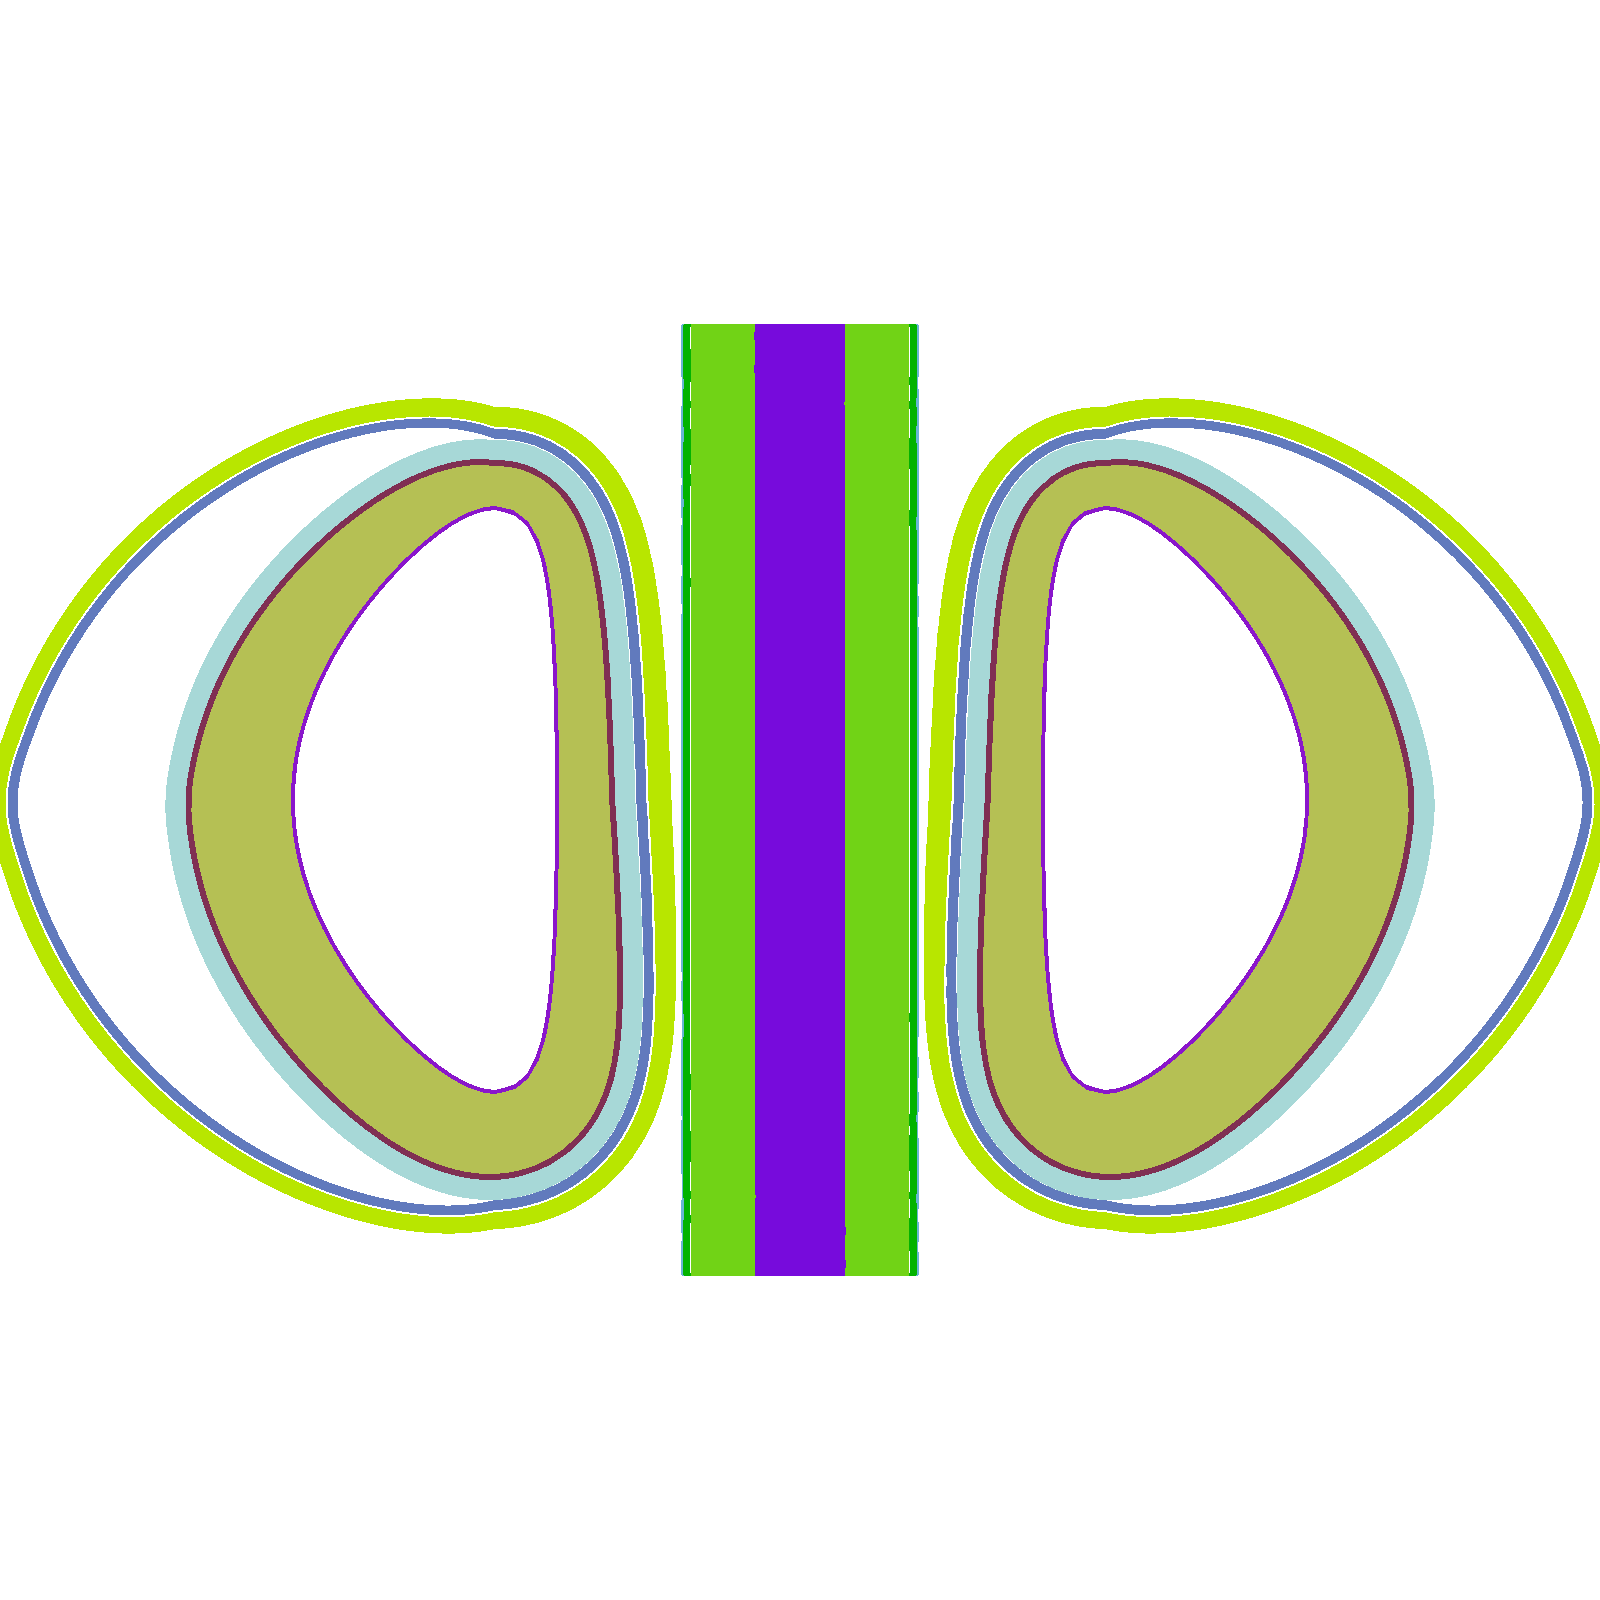

In [16]:
# builds the openmc model
my_model = openmc.Model(
    materials=materials, geometry=geometry, settings=settings, tallies=tallies
)


p = openmc.Plot()
p.origin = (0, 10, 0)
p.pixels = (1600, 1600)
p.width = (1600, 1600)
p.basis = 'xz'
p.color_by = 'material'
openmc.plot_inline([p])



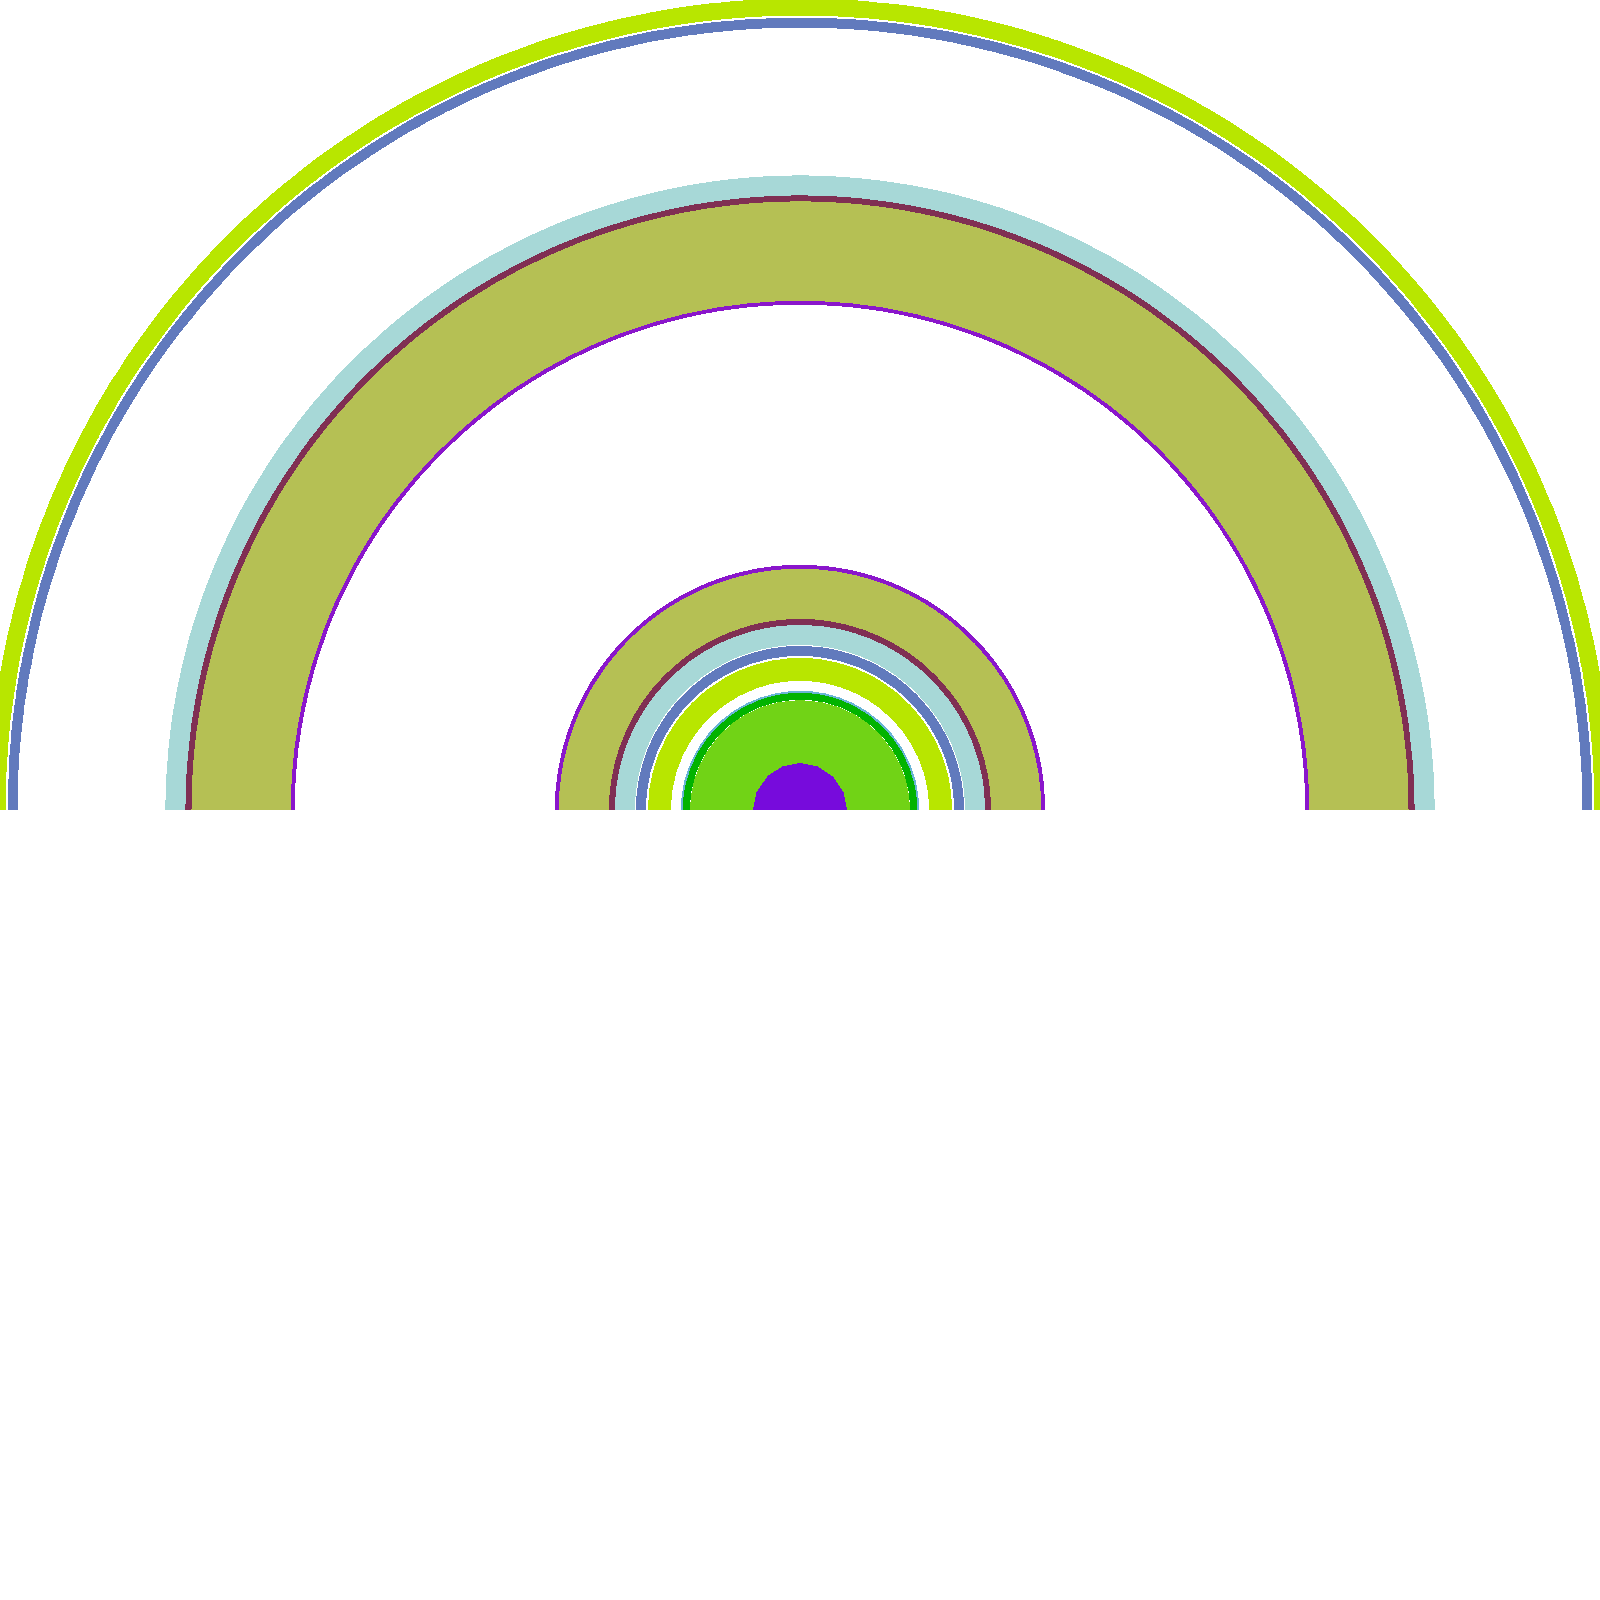

In [17]:


p.basis = 'xy'
openmc.plot_inline(p)


In [18]:
my_model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

PosixPath('/home/vscode/3 breeders together/statepoint.50.h5')

In [19]:
import openmc
sp = openmc.StatePoint("statepoint.50.h5")

for tally_id, tally in sp.tallies.items():
    print(f"Tally ID: {tally_id}, Tally Name: {tally.name}")


Tally ID: 3, Tally Name: tbr
Tally ID: 2, Tally Name: heating
Tally ID: 5, Tally Name: flux
Tally ID: 7, Tally Name: absorption
Tally ID: 9, Tally Name: damage energy
Tally ID: 6, Tally Name: energetic flux


In [20]:
heating_tally = sp.get_tally(name="heating")
print(heating_tally)
'''uheating_tally = sp.get_tally(name="uheating")
print(uheating_tally)'''


Tally
	ID             =	2
	Name           =	heating
	Filters        =	MeshFilter
	Nuclides       =	total
	Scores         =	['heating']
	Estimator      =	tracklength
	Multiply dens. =	True


'uheating_tally = sp.get_tally(name="uheating")\nprint(uheating_tally)'

In [21]:
# Get heating slice
'''
uheating = uheating_tally.get_slice(scores=['heating'])
uheating_umesh = uheating.find_filter(openmc.MeshFilter).mesh
print(f"The reactor has {4*uheating.mean.sum()/1e6} MeV/source particle deposited")
print(f"Standard deviation on the heating is {uheating.std_dev.sum()/1e6}")'''

heating = heating_tally.get_slice(scores=['heating'])
heating_umesh = heating.find_filter(openmc.MeshFilter).mesh
print(f"The reactor has {4*heating.mean.sum()/1e6} MeV/source particle deposited")
print(f"Standard deviation on the heating is {heating.std_dev.sum()/1e6}MeV/source particle deposited")

The reactor has 31.96604891276811 MeV/source particle deposited
Standard deviation on the heating is 1.077889062779049MeV/source particle deposited


In [22]:
'''uheating_filter = uheating.find_filter(openmc.MeshFilter)
uheating_mesh = uheating_filter.mesh'''

'uheating_filter = uheating.find_filter(openmc.MeshFilter)\nuheating_mesh = uheating_filter.mesh'

In [23]:
'''
centroids = uheating_mesh.centroids  # not needed in the next release of openmc
mesh_vols = uheating_mesh.volumes  # not needed in the next release of openmc

uheating_mesh.write_data_to_vtk(
    datasets={"mean": heating.mean.flatten()},
    filename="heating results.vtk",
)
uheating_mesh.write_data_to_vtk(
    datasets={"std_dev": heating.std_dev.flatten()},
    filename="heating std dev results.vtk",
)'''

'\ncentroids = uheating_mesh.centroids  # not needed in the next release of openmc\nmesh_vols = uheating_mesh.volumes  # not needed in the next release of openmc\n\nuheating_mesh.write_data_to_vtk(\n    datasets={"mean": heating.mean.flatten()},\n    filename="heating results.vtk",\n)\nuheating_mesh.write_data_to_vtk(\n    datasets={"std_dev": heating.std_dev.flatten()},\n    filename="heating std dev results.vtk",\n)'

In [24]:
# extracts the mesh tally result
tbr_tally = sp.get_tally(name="tbr")
print(tbr_tally.shape)
tdf=tbr_tally.get_pandas_dataframe()
print(tdf.head())
'''
# extracts the mesh tally result
utbr_tally = sp.get_tally(name="utbr")
print(utbr_tally.shape)
utbr_tally.get_pandas_dataframe()'''

(1, 2, 1)
  particle nuclide   score      mean  std. dev.
0  neutron     Li6  (n,Xt)  0.000063   0.000005
1  neutron     Li7  (n,Xt)  0.000000   0.000000


'\n# extracts the mesh tally result\nutbr_tally = sp.get_tally(name="utbr")\nprint(utbr_tally.shape)\nutbr_tally.get_pandas_dataframe()'

In [25]:
tbr=tbr_tally.get_slice(scores=["(n,Xt)"])
#tbr=tbr_tally.find_filter([openmc.MaterialFilter])
#tbr_umesh = tbr.find_filter(openmc.MaterialFilter)
print(f"The reactor has a TBR of {tbr.mean.sum()}")
print(f"Standard deviation on the TBR is {tbr.std_dev.sum()}")

'''
utbr=utbr_tally.get_slice(scores=["(n,Xt)"])
#tbr=tbr_tally.find_filter([openmc.MaterialFilter])
#tbr_umesh = tbr.find_filter(openmc.MaterialFilter)
print(f"The reactor has a TBR of {utbr.mean.sum()}")
print(f"Standard deviation on the TBR is {utbr.std_dev.sum()}")'''

The reactor has a TBR of 6.298275446947705e-05
Standard deviation on the TBR is 5.063962098128546e-06


'\nutbr=utbr_tally.get_slice(scores=["(n,Xt)"])\n#tbr=tbr_tally.find_filter([openmc.MaterialFilter])\n#tbr_umesh = tbr.find_filter(openmc.MaterialFilter)\nprint(f"The reactor has a TBR of {utbr.mean.sum()}")\nprint(f"Standard deviation on the TBR is {utbr.std_dev.sum()}")'

In [26]:
flux=sp.get_tally(name='flux')
print(flux.shape)
#flux_umesh=flux.find_filter(openmc.SpatialLegendreFilter)
fdf=flux.get_pandas_dataframe()
print(fdf.head())

'''
uflux=sp.get_tally(name='uflux')
print(uflux.shape)
uflux_umesh=uflux.find_filter(openmc.MeshFilter).mesh
centroids = uflux_umesh.centroids  # not needed in the next release of openmc
mesh_vols = uflux_umesh.volumes  # not needed in the next release of openmc'''

(1001, 1, 1)
  spatiallegendre nuclide score        mean  std. dev.
0              P0   total  flux  101.097064   0.028970
1              P1   total  flux    0.032282   0.021950
2              P2   total  flux  -30.433063   0.012481
3              P3   total  flux   -0.037382   0.018567
4              P4   total  flux    2.651452   0.014133


"\nuflux=sp.get_tally(name='uflux')\nprint(uflux.shape)\nuflux_umesh=uflux.find_filter(openmc.MeshFilter).mesh\ncentroids = uflux_umesh.centroids  # not needed in the next release of openmc\nmesh_vols = uflux_umesh.volumes  # not needed in the next release of openmc"

In [27]:
print(fdf.index.names)
print(fdf.columns)

[None]
Index(['spatiallegendre', 'nuclide', 'score', 'mean', 'std. dev.'], dtype='object')


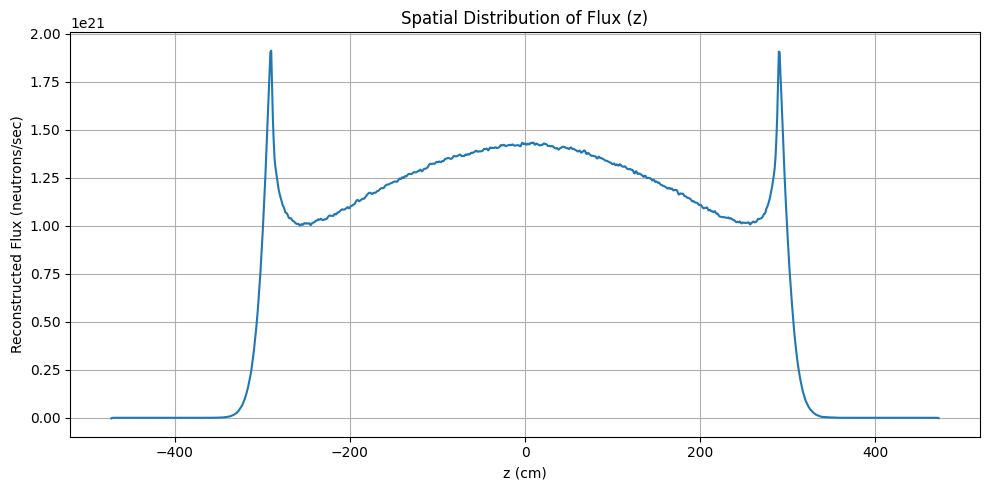

In [28]:
# Spatial domain (along z)
zmin = -472.2
zmax = 472.2  
order=1000
z_vals = np.linspace(zmin, zmax, 1000)
n = np.arange(order + 1)
a_n = (2*n + 1)/2 * fdf['mean']
phi = np.polynomial.Legendre(a_n/10, domain=(zmin, zmax))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(z_vals, phi(z_vals)*1.6e20)
plt.xlabel('z (cm)')
plt.ylabel('Reconstructed Flux (neutrons/sec)')
plt.title('Spatial Distribution of Flux (z)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
print(flux.mean.sum())
print(flux.std_dev.sum())
'''
print(uflux.mean.sum())
print(uflux.std_dev.sum())'''

75.96294146830057
0.8892549566444687


'\nprint(uflux.mean.sum())\nprint(uflux.std_dev.sum())'

In [30]:
'''uflux_mean = uflux.mean.reshape(*mesh1.dimension)
plt.figure(figsize=(10,10))
plt.imshow(uflux_mean[:, 50, :], origin='lower')'''

"uflux_mean = uflux.mean.reshape(*mesh1.dimension)\nplt.figure(figsize=(10,10))\nplt.imshow(uflux_mean[:, 50, :], origin='lower')"

In [31]:
wall_loading=flux*2.2528e-10

In [32]:

'''flux_umesh.write_data_to_vtk(
    datasets={"mean": uflux.mean.flatten()},
    filename="flux_results.vtk",
)
flux_umesh.write_data_to_vtk(
    datasets={"std_dev": uflux.std_dev.flatten()},
    filename="flux_std_dev_results.vtk",
)'''

'flux_umesh.write_data_to_vtk(\n    datasets={"mean": uflux.mean.flatten()},\n    filename="flux_results.vtk",\n)\nflux_umesh.write_data_to_vtk(\n    datasets={"std_dev": uflux.std_dev.flatten()},\n    filename="flux_std_dev_results.vtk",\n)'

In [33]:
flux1=sp.get_tally(name='energetic flux')
print(flux1.shape)
energy=np.logspace(np.log10(1e-5), np.log10(20.0e6), 1000)
print(energy.shape)
flux2 = flux1.mean.flatten()
print("Energy shape:", np.shape(energy))
print("Flux2 shape:", np.shape(flux2))


(1000, 1, 1)
(1000,)
Energy shape: (1000,)
Flux2 shape: (1000,)


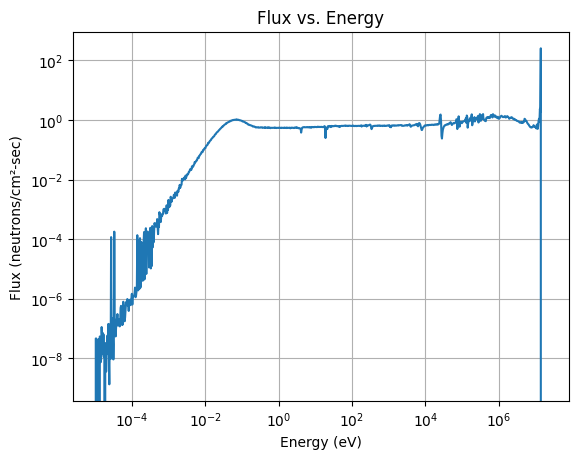

In [34]:
import numpy as np
import matplotlib.pyplot as plt

plt.plot(energy,flux2, label='Total Neutron Flux')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (eV)')
plt.ylabel('Flux (neutrons/cm²-sec)')
plt.title('Flux vs. Energy')
plt.grid(True)
plt.show()